
# Esempio di simulazione e visualizzazione atomistica: OVITO + py3Dmol

Questo notebook mostra un workflow semplice ma rappresentativo, pensato per essere eseguito in **VS Code/Jupyter** e pubblicato in un **Jupyter Book**.

Faremo due cose:

1. **Ag FCC + Lennard–Jones**  
   Costruiamo un piccolo cristallo di argento, eseguiamo una breve dinamica molecolare NVE in unità ridotte, esportiamo una traiettoria e usiamo **OVITO** per analizzarla (RDF). La visualizzazione 3D nel notebook viene affidata a **py3Dmol**.

2. **Ala\(_4\) in acqua**  
   Costruiamo un tetrapeptide di alanina (`Ala-Ala-Ala-Ala`) in una scatola d'acqua illustrativa e lo visualizziamo con **py3Dmol**.

> **Scelta progettuale importante**
>
> In questo notebook **non usiamo `ovito.gui`, `create_ipywidget()`, `Viewport` o `render_image()`**.  
> In VS Code/macOS e nelle build headless di Jupyter Book queste funzioni grafiche possono essere fragili o arrivare a terminare il kernel. Qui usiamo OVITO per ciò che è più robusto nel notebook: **I/O, pipeline e analisi**. Per il 3D interattivo usiamo py3Dmol.

> **Nota fisica**
>
> Lennard–Jones non è un modello realistico della coesione metallica dell'Ag. Per simulazioni quantitative dell'argento si usano in genere potenziali many-body, per esempio EAM. Qui LJ è scelto perché è trasparente e adatto a un esempio didattico.



## 0. Ambiente

Dalla root del repository, con la `.venv` attiva:

```bash
python -m pip install -U ovito py3Dmol ipykernel
```

Nel tuo ambiente attuale sono già installati:

- Python 3.12
- OVITO 3.16.1
- py3Dmol 2.5.5

Per rendere il repository riproducibile, registra poi le dipendenze nel `pyproject.toml` (o nel lockfile del package manager che usi).

Il notebook scrive tutti i file generati nella sottocartella locale `generated/`.


In [ ]:
# Verifica minima dell'ambiente.
# Questa cella NON apre componenti GUI di OVITO.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ovito
import py3Dmol

print("Python :", sys.version.split()[0])
print("Kernel :", sys.executable)
print("OVITO  :", ovito.version_string)
print("py3Dmol:", getattr(py3Dmol, "__version__", "versione non esposta"))
print("cwd    :", Path.cwd())


Python : 3.12.14
Kernel : /Users/francesco/Desktop/computational-course/.venv/bin/python
OVITO  : 3.16.1
py3Dmol: 2.5.5
cwd    : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook



---

# 1. Ag FCC con Lennard–Jones

Usiamo il potenziale 12–6

\[
U(r)=4\varepsilon
\left[
\left(\frac{\sigma}{r}\right)^{12}
-
\left(\frac{\sigma}{r}\right)^6
\right].
\]

La dinamica viene integrata in **unità ridotte Lennard–Jones**:

\[
\sigma=\varepsilon=m=1.
\]

Per l'export assegniamo una scala di lunghezza illustrativa a \(\sigma\), scegliendola in modo che un reticolo FCC vicino al minimo LJ abbia un parametro reticolare prossimo a quello dell'Ag. Questa conversione serve solo a rendere familiari le distanze in Å; **non costituisce una parametrizzazione dell'argento**.

Simuliamo \(4\times4\times4\) celle convenzionali FCC:

\[
4^3\times4=256\ \text{atomi}.
\]



## 1.1 Funzioni: reticolo, forze e writer XYZ

La **minimum-image convention** gestisce le condizioni periodiche.  
Per 256 atomi possiamo permetterci un calcolo vettorializzato di tutte le coppie: è semplice da leggere ed è sufficiente per un esempio didattico.


In [ ]:
from pathlib import Path

import numpy as np


def make_fcc(n_cells: int, a_star: float):
    """Costruisce un cristallo FCC cubico periodico in unità LJ."""
    basis = np.array(
        [
            [0.0, 0.0, 0.0],
            [0.0, 0.5, 0.5],
            [0.5, 0.0, 0.5],
            [0.5, 0.5, 0.0],
        ]
    )

    cells = np.array(
        [
            [i, j, k]
            for i in range(n_cells)
            for j in range(n_cells)
            for k in range(n_cells)
        ],
        dtype=float,
    )

    positions = (cells[:, None, :] + basis[None, :, :]).reshape(-1, 3) * a_star
    box_length = n_cells * a_star
    return positions, box_length


def lj_forces(positions: np.ndarray, box_length: float, r_cut: float = 2.5):
    """Restituisce forze e energia potenziale LJ in unità ridotte."""
    n_atoms = len(positions)
    ii, jj = np.triu_indices(n_atoms, k=1)

    rij = positions[ii] - positions[jj]
    rij -= box_length * np.rint(rij / box_length)

    r2 = np.einsum("ij,ij->i", rij, rij)
    keep = r2 < r_cut**2

    ii = ii[keep]
    jj = jj[keep]
    rij = rij[keep]
    r2 = r2[keep]

    inv_r2 = 1.0 / r2
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    # F_ij = 24 (2 r^-12 - r^-6) r^-2 * r_ij
    prefactor = 24.0 * (2.0 * inv_r12 - inv_r6) * inv_r2
    fij = prefactor[:, None] * rij

    forces = np.zeros_like(positions)
    np.add.at(forces, ii, fij)
    np.add.at(forces, jj, -fij)

    # Potenziale traslato: U(rc)=0
    inv_rc6 = r_cut**-6
    u_shift = 4.0 * (inv_rc6**2 - inv_rc6)
    potential = np.sum(4.0 * (inv_r12 - inv_r6) - u_shift)

    return forces, potential


def write_extended_xyz(path, frames, box_length_A: float, sigma_A: float):
    """Scrive una traiettoria Extended XYZ leggibile da OVITO."""
    path = Path(path)

    with path.open("w", encoding="utf-8") as handle:
        for iframe, frame in enumerate(frames):
            xyz = frame * sigma_A

            handle.write(f"{len(xyz)}\n")
            handle.write(
                'Lattice="'
                f"{box_length_A:.8f} 0 0 "
                f"0 {box_length_A:.8f} 0 "
                f"0 0 {box_length_A:.8f}"
                '" Properties=species:S:1:pos:R:3 '
                f'pbc="T T T" Frame={iframe}\n'
            )

            for x, y, z in xyz:
                handle.write(f"Ag {x:.8f} {y:.8f} {z:.8f}\n")


def write_single_xyz(path, positions_star, sigma_A: float):
    """Scrive un singolo frame XYZ, comodo per py3Dmol."""
    xyz = positions_star * sigma_A
    path = Path(path)

    with path.open("w", encoding="utf-8") as handle:
        handle.write(f"{len(xyz)}\n")
        handle.write("Ag FCC Lennard-Jones - final frame\n")
        for x, y, z in xyz:
            handle.write(f"Ag {x:.8f} {y:.8f} {z:.8f}\n")



## 1.2 Breve dinamica NVE con velocity-Verlet

Assegniamo velocità casuali, rimuoviamo il moto del centro di massa e integriamo con **velocity-Verlet**.

La simulazione è volutamente breve: ci interessa generare una piccola traiettoria realistica quanto basta per mostrare il workflow, non fare produzione scientifica.


Atomi              : 256
Frame salvati      : 23
L box              : 16.344 Å
a FCC              : 4.086 Å
T* iniziale/finale : 0.1200 / 0.0581
Drift relativo E   : 2.29e-06
Traiettoria        : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook/generated/ag_lj_trajectory.xyz
Frame finale       : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook/generated/ag_lj_final.xyz


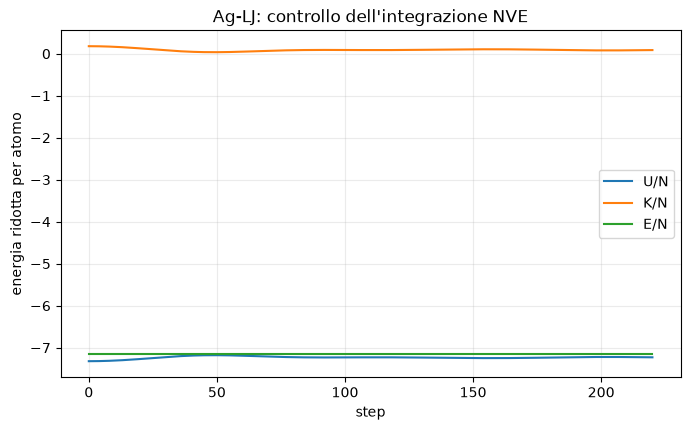

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OUT = Path("generated")
OUT.mkdir(exist_ok=True)

# --- Parametri didattici ---
n_cells = 4
a_star = 2 ** (2 / 3)  # valore vicino all'equilibrio FCC LJ
sigma_A = 2.574  # Å: sola scala illustrativa
temperature_star = 0.12
dt_star = 0.002
n_steps = 220
save_every = 10
r_cut_star = 2.5
seed = 7

positions, box_length = make_fcc(n_cells, a_star)
n_atoms = len(positions)

rng = np.random.default_rng(seed)
velocities = rng.normal(size=positions.shape)
velocities -= velocities.mean(axis=0)

dof = 3 * n_atoms - 3
current_T = np.sum(velocities**2) / dof
velocities *= np.sqrt(temperature_star / current_T)

forces, potential = lj_forces(positions, box_length, r_cut_star)

trajectory = []
thermo = []

for step in range(n_steps + 1):
    kinetic = 0.5 * np.sum(velocities**2)
    temperature = 2.0 * kinetic / dof
    total = potential + kinetic

    thermo.append((step, potential, kinetic, total, temperature))

    if step % save_every == 0:
        trajectory.append(positions.copy())

    if step == n_steps:
        break

    # velocity-Verlet
    velocities += 0.5 * dt_star * forces
    positions = (positions + dt_star * velocities) % box_length

    new_forces, potential = lj_forces(positions, box_length, r_cut_star)
    velocities += 0.5 * dt_star * new_forces
    forces = new_forces

thermo = np.asarray(thermo)

trajectory_path = OUT / "ag_lj_trajectory.xyz"
final_xyz_path = OUT / "ag_lj_final.xyz"
box_length_A = box_length * sigma_A

write_extended_xyz(
    trajectory_path,
    trajectory,
    box_length_A=box_length_A,
    sigma_A=sigma_A,
)
write_single_xyz(final_xyz_path, trajectory[-1], sigma_A=sigma_A)

energy_drift = (thermo[-1, 3] - thermo[0, 3]) / abs(thermo[0, 3])

print(f"Atomi              : {n_atoms}")
print(f"Frame salvati      : {len(trajectory)}")
print(f"L box              : {box_length_A:.3f} Å")
print(f"a FCC              : {a_star * sigma_A:.3f} Å")
print(f"T* iniziale/finale : {thermo[0, 4]:.4f} / {thermo[-1, 4]:.4f}")
print(f"Drift relativo E   : {energy_drift:.2e}")
print(f"Traiettoria        : {trajectory_path.resolve()}")
print(f"Frame finale       : {final_xyz_path.resolve()}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thermo[:, 0], thermo[:, 1] / n_atoms, label="U/N")
ax.plot(thermo[:, 0], thermo[:, 2] / n_atoms, label="K/N")
ax.plot(thermo[:, 0], thermo[:, 3] / n_atoms, label="E/N")
ax.set_xlabel("step")
ax.set_ylabel("energia ridotta per atomo")
ax.set_title("Ag-LJ: controllo dell'integrazione NVE")
ax.grid(alpha=0.25)
ax.legend()
plt.show()



## 1.3 OVITO come strumento di analisi

Qui OVITO lavora **senza aprire una scena grafica**.

Il pattern fondamentale è:

```python
pipeline = import_file("trajectory.xyz")
pipeline.modifiers.append(...)
data = pipeline.compute(frame)
```

Useremo il `RadialDistributionFunctionModifier`, che produce la tabella `coordination-rdf`.


Frame letti da OVITO: 23
Atomi nell'ultimo frame: 256
PBC: (True, True, True)


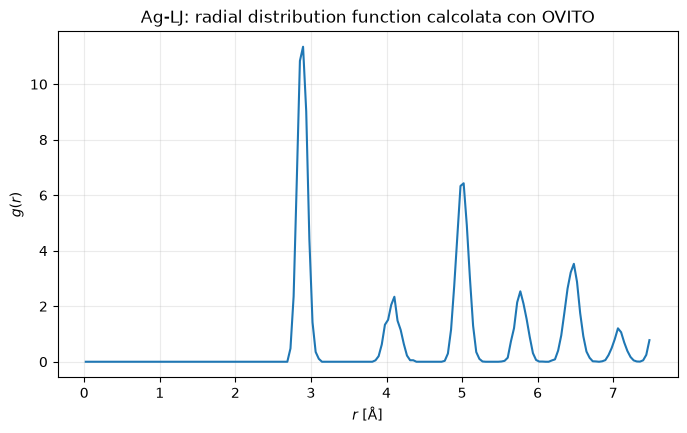

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ovito.io import import_file
from ovito.modifiers import RadialDistributionFunctionModifier

trajectory_path = Path("generated/ag_lj_trajectory.xyz")

if not trajectory_path.exists():
    raise FileNotFoundError(
        "Manca generated/ag_lj_trajectory.xyz. "
        "Esegui prima la cella della dinamica Ag-LJ."
    )

pipeline = import_file(str(trajectory_path))

print("Frame letti da OVITO:", pipeline.num_frames)

last_frame = pipeline.num_frames - 1
raw_data = pipeline.compute(last_frame)

print("Atomi nell'ultimo frame:", raw_data.particles.count)
print("PBC:", tuple(bool(v) for v in raw_data.cell.pbc))

pipeline.modifiers.append(
    RadialDistributionFunctionModifier(
        cutoff=7.5,
        number_of_bins=180,
    )
)

data = pipeline.compute(last_frame)
rdf = np.asarray(data.tables["coordination-rdf"].xy())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rdf[:, 0], rdf[:, 1])
ax.set_xlabel(r"$r$ [Å]")
ax.set_ylabel(r"$g(r)$")
ax.set_title("Ag-LJ: radial distribution function calcolata con OVITO")
ax.grid(alpha=0.25)
plt.show()



### Recap OVITO

Le tre operazioni da ricordare sono:

```python
from ovito.io import import_file

pipeline = import_file("trajectory.xyz")
data = pipeline.compute(frame)
```

e, per aggiungere un'analisi:

```python
from ovito.modifiers import RadialDistributionFunctionModifier

pipeline.modifiers.append(
    RadialDistributionFunctionModifier(cutoff=7.5)
)
data = pipeline.compute()
```

In un workflow più realistico potresti sostituire l'XYZ con un dump LAMMPS e aggiungere modifier per CNA/PTM, strain, difetti, selezioni, ecc.

> Per questo esempio non chiamiamo funzioni di rendering OVITO dentro il kernel Jupyter.



## 1.4 Visualizzazione interattiva dell'Ag con py3Dmol

La stessa configurazione finale viene mostrata in WebGL con py3Dmol.  
Questa soluzione è leggera e si adatta bene anche a una pagina Jupyter Book.

Trascina per ruotare e usa la rotella/trackpad per lo zoom.


In [ ]:
from pathlib import Path

import py3Dmol

final_xyz_path = Path("generated/ag_lj_final.xyz")

if not final_xyz_path.exists():
    raise FileNotFoundError(
        "Manca generated/ag_lj_final.xyz. Esegui prima la cella della dinamica Ag-LJ."
    )

xyz_text = final_xyz_path.read_text(encoding="utf-8")

view = py3Dmol.view(width=850, height=520)
view.addModel(xyz_text, "xyz")
view.setStyle(
    {"elem": "Ag"},
    {
        "sphere": {"scale": 0.38, "color": "silver"},
    },
)
view.setBackgroundColor("white")
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


---

# 2. Ala\(_4\) in acqua con py3Dmol

Passiamo a un esempio molecolare: il tetrapeptide

\[
\mathrm{Ala-Ala-Ala-Ala}
\]

immerso in una piccola scatola di acqua.

Per mantenere il notebook **offline e riproducibile**, le coordinate del peptide sono incorporate nel notebook. Il solvente viene generato geometricamente con un semplice criterio anti-overlap.

> Questa **non è una solvatazione equilibrata** e non sostituisce un workflow con OpenMM, GROMACS, AMBER, Packmol, ecc. Lo scopo qui è mostrare strutture, selezioni e stili di py3Dmol.


In [ ]:
ALA4_PDB = "ATOM      1  N   ALA A   1      -4.710   2.897   0.394  1.00  0.00           N\nATOM      2  CA  ALA A   1      -3.885   1.694   0.171  1.00  0.00           C\nATOM      3  C   ALA A   1      -3.151   1.309   1.476  1.00  0.00           C\nATOM      4  O   ALA A   1      -3.185   2.005   2.488  1.00  0.00           O\nATOM      5  CB  ALA A   1      -2.894   1.958  -0.956  1.00  0.00           C\nATOM      6  N   ALA A   2      -2.464   0.118   1.412  1.00  0.00           N\nATOM      7  CA  ALA A   2      -1.766  -0.437   2.573  1.00  0.00           C\nATOM      8  C   ALA A   2      -0.546  -1.261   2.111  1.00  0.00           C\nATOM      9  O   ALA A   2      -0.074  -2.195   2.751  1.00  0.00           O\nATOM     10  CB  ALA A   2      -2.709  -1.272   3.429  1.00  0.00           C\nATOM     11  N   ALA A   3       0.045  -0.776   0.966  1.00  0.00           N\nATOM     12  CA  ALA A   3       1.296  -1.300   0.436  1.00  0.00           C\nATOM     13  C   ALA A   3       1.886  -0.225  -0.498  1.00  0.00           C\nATOM     14  O   ALA A   3       1.232   0.753  -0.862  1.00  0.00           O\nATOM     15  CB  ALA A   3       1.071  -2.605  -0.318  1.00  0.00           C\nATOM     16  N   ALA A   4       3.191  -0.443  -0.889  1.00  0.00           N\nATOM     17  CA  ALA A   4       3.791   0.377  -1.944  1.00  0.00           C\nATOM     18  C   ALA A   4       3.456  -0.253  -3.296  1.00  0.00           C\nATOM     19  O   ALA A   4       3.107  -1.409  -3.488  1.00  0.00           O\nATOM     20  CB  ALA A   4       5.299   0.447  -1.766  1.00  0.00           C\nATOM     21  OXT ALA A   4       3.620   0.595  -4.331  1.00  0.00           O\n"


## 2.1 Costruiamo una scatola d'acqua illustrativa

Ogni molecola H\(_2\)O usa una geometria fissa:

- \(r_{\mathrm{OH}}=0.9572\) Å
- \(\angle\mathrm{HOH}=104.52^\circ\)

Gli ossigeni vengono accettati solo se non sono troppo vicini al peptide o ad altre molecole d'acqua.


In [ ]:
from pathlib import Path

import numpy as np


def random_unit_vector(rng):
    v = rng.normal(size=3)
    return v / np.linalg.norm(v)


def pdb_coordinates(pdb_text):
    lines = [
        line for line in pdb_text.splitlines() if line.startswith(("ATOM", "HETATM"))
    ]
    xyz = np.array(
        [
            [
                float(line[30:38]),
                float(line[38:46]),
                float(line[46:54]),
            ]
            for line in lines
        ]
    )
    return lines, xyz


def make_ala4_water_box(
    peptide_pdb,
    n_waters=100,
    box_length=22.0,
    min_peptide_distance=2.7,
    min_oo_distance=2.4,
    seed=11,
):
    rng = np.random.default_rng(seed)
    peptide_lines, peptide_xyz = pdb_coordinates(peptide_pdb)

    # Centriamo il peptide nella scatola.
    center = 0.5 * (peptide_xyz.min(axis=0) + peptide_xyz.max(axis=0))
    peptide_xyz_centered = peptide_xyz - center

    centered_lines = []
    for line, xyz in zip(peptide_lines, peptide_xyz_centered):
        x, y, z = xyz
        centered_lines.append(f"{line[:30]}{x:8.3f}{y:8.3f}{z:8.3f}{line[54:]}")

    half = box_length / 2
    oxygens = []

    for _ in range(250_000):
        if len(oxygens) >= n_waters:
            break

        oxygen = rng.uniform(-half + 1.2, half - 1.2, size=3)

        d_peptide = np.linalg.norm(
            peptide_xyz_centered - oxygen,
            axis=1,
        )
        if d_peptide.min() < min_peptide_distance:
            continue

        if oxygens:
            d_oo = np.linalg.norm(np.asarray(oxygens) - oxygen, axis=1)
            if d_oo.min() < min_oo_distance:
                continue

        oxygens.append(oxygen)

    if len(oxygens) != n_waters:
        raise RuntimeError(
            f"Packing incompleto: {len(oxygens)}/{n_waters} molecole d'acqua."
        )

    r_oh = 0.9572
    hoh = np.deg2rad(104.52)

    pdb_lines = [
        f"CRYST1{box_length:9.3f}{box_length:9.3f}{box_length:9.3f}"
        "  90.00  90.00  90.00 P 1           1"
    ]
    pdb_lines.extend(centered_lines)

    serial = len(centered_lines) + 1

    for resid, oxygen in enumerate(oxygens, start=1):
        u = random_unit_vector(rng)

        w = random_unit_vector(rng)
        w -= np.dot(w, u) * u
        w /= np.linalg.norm(w)

        h1 = oxygen + r_oh * u
        h2 = oxygen + r_oh * (np.cos(hoh) * u + np.sin(hoh) * w)

        for atom_name, element, xyz in (
            ("O", "O", oxygen),
            ("H1", "H", h1),
            ("H2", "H", h2),
        ):
            x, y, z = xyz
            pdb_lines.append(
                f"HETATM{serial:5d} {atom_name:<4s} HOH W{resid:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}"
                f"  1.00  0.00          {element:>2s}"
            )
            serial += 1

    pdb_lines.append("END")
    return "\n".join(pdb_lines) + "\n"


OUT = Path("generated")
OUT.mkdir(exist_ok=True)

solvated_pdb = make_ala4_water_box(
    ALA4_PDB,
    n_waters=100,
)

pdb_path = OUT / "ala4_water.pdb"
pdb_path.write_text(solvated_pdb, encoding="utf-8")

print("Sistema:", "Ala4 + 100 H2O")
print("File   :", pdb_path.resolve())


Sistema: Ala4 + 100 H2O
File   : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook/generated/ala4_water.pdb



## 2.2 Viewer py3Dmol: peptide + solvente

Usiamo selettori diversi per peptide e acqua:

- `chain="A"` → tetrapeptide;
- `resn="HOH"` → solvente;
- `elem="O"` / `elem="H"` → stile differente per gli atomi dell'acqua.


In [ ]:
from pathlib import Path

import py3Dmol

pdb_path = Path("generated/ala4_water.pdb")

if not pdb_path.exists():
    raise FileNotFoundError(
        "Manca generated/ala4_water.pdb. "
        "Esegui prima la cella che costruisce il sistema Ala4 + acqua."
    )

pdb_text = pdb_path.read_text(encoding="utf-8")

view = py3Dmol.view(width=850, height=560)
view.addModel(pdb_text, "pdb")

# Peptide: evidente.
view.setStyle(
    {"chain": "A"},
    {
        "stick": {"radius": 0.20},
        "sphere": {"scale": 0.30},
    },
)

# Solvente: più leggero.
view.setStyle(
    {"resn": "HOH", "elem": "O"},
    {
        "sphere": {
            "scale": 0.18,
            "color": "red",
            "opacity": 0.35,
        }
    },
)
view.setStyle(
    {"resn": "HOH", "elem": "H"},
    {
        "sphere": {
            "scale": 0.09,
            "color": "white",
            "opacity": 0.25,
        }
    },
)

view.setBackgroundColor("white")
view.zoomTo({"chain": "A"})
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 2.3 Seconda vista: peptide in primo piano

Una tecnica comune è mantenere il solvente quasi invisibile e concentrare la vista sul soluto.


In [ ]:
import py3Dmol

view2 = py3Dmol.view(width=850, height=500)
view2.addModel(pdb_text, "pdb")

view2.setStyle(
    {"chain": "A"},
    {
        "stick": {"radius": 0.24},
        "sphere": {"scale": 0.34},
    },
)

view2.setStyle(
    {"resn": "HOH", "elem": "O"},
    {
        "sphere": {
            "scale": 0.14,
            "color": "red",
            "opacity": 0.15,
        }
    },
)

view2.setBackgroundColor("white")
view2.zoomTo({"chain": "A"})
view2.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


---

# 3. Recap operativo

| Obiettivo | Strumento | Pattern |
|---|---|---|
| Leggere una traiettoria atomistica | OVITO | `import_file(...)` |
| Costruire una pipeline di analisi | OVITO | `pipeline.modifiers.append(...)` |
| Calcolare RDF / proprietà strutturali | OVITO | `pipeline.compute(...)` |
| Mostrare un solido nel notebook | py3Dmol | `addModel(..., "xyz")` |
| Mostrare PDB / molecole / solvente | py3Dmol | `addModel(..., "pdb")` |
| Selezionare e stilizzare parti del sistema | py3Dmol | `setStyle(selection, style)` |

### OVITO — schema minimo

```python
from ovito.io import import_file
from ovito.modifiers import RadialDistributionFunctionModifier

pipeline = import_file("trajectory.xyz")
pipeline.modifiers.append(
    RadialDistributionFunctionModifier(cutoff=7.5)
)
data = pipeline.compute()
```

### py3Dmol — schema minimo

```python
import py3Dmol

view = py3Dmol.view()
view.addModel(structure_text, "pdb")
view.setStyle({"chain": "A"}, {"stick": {}})
view.zoomTo()
view.show()
```



# 4. Note per VS Code, Jupyter Book e Git

## In VS Code

Se riavvii il kernel, usa **Restart Kernel and Run All Cells**.  
Le celle che leggono file generati controllano esplicitamente che i file esistano e mostrano un errore comprensibile se la sezione precedente non è stata eseguita.

## In Jupyter Book

Questo notebook evita deliberatamente il rendering GUI di OVITO. La build deve soltanto:

1. installare le dipendenze;
2. eseguire il notebook;
3. conservare gli output py3Dmol e Matplotlib.

py3Dmol produce HTML/JavaScript per il viewer 3D; verifica quindi il risultato finale della build nel browser.

## File prodotti

Dopo `Run All` dovresti ottenere:

```text
generated/
├── ag_lj_trajectory.xyz
├── ag_lj_final.xyz
└── ala4_water.pdb
```

La cartella `generated/` può essere ignorata da Git se preferisci rigenerare questi file durante la build:

```gitignore
generated/
```

## Dipendenze consigliate nel progetto

Con le versioni che stai usando attualmente:

```toml
[dependency-groups]
dev = [
  # ...dipendenze già presenti...
  "ovito==3.16.1.post1",
  "py3Dmol==2.5.5",
  "ipykernel==7.4.0",
]
```

Se `jupyter` è già nel gruppo `dev`, non serve aggiungere altro per questo notebook.
